# AURA Tutorial: IPF Lung (Multi-Sample Xenium)

This tutorial demonstrates **AURA** on a multi-sample IPF lung dataset
(Vannan et al., *Nature Genetics*, 2025; Xenium custom 343-gene panel).

It covers features **not shown** in the lymph node tutorial:

1. **Multi-sample mode** — within-sample kNN and within-sample permutation
2. **Beta heatmap** — full gene × composition-axis effect matrix
3. **Data-driven spillover detection** — `learn_canonical` + `spillover_filter`
4. **Distance-decay validation** — confirm spillover suspects with spatial decay

### Dataset summary

| Property | Value |
|:---|:---|
| Platform | 10x Xenium custom panel |
| Cells | 1,630,319 |
| Genes | 343 |
| Samples | 45 TMA cores (35 donors: 9 healthy, 26 IPF) |
| Composition groups | 9 (collapsed from 47 fine types) |
| Segmentation | Default Xenium (15 µm nuclear expansion) |

The default Xenium segmentation is known to produce transcript spillover
between adjacent cells. AURA's spillover filter distinguishes genuine
composition-dependent regulation from leakage artifacts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import aura
from aura.io import TissueData

import logging
logging.basicConfig(level=logging.INFO, format='%(name)s: %(message)s')

print(f'AURA version: {aura.__version__}')

AURA version: 0.1.0


In [2]:
# ================================================================
# Paths and parameters
# ================================================================
DATA_PATH = '/Users/mchen12/SpatialHeterogeneity/data/IPF/ipf_xenium.h5ad'

K = 30              # neighbors (within-sample)
N_PERM = 5000       # permutations (within-sample)
ALPHA = 0.05        # FDR threshold

---
## 1. Load and Prepare Multi-Sample Data

Unlike the lymph node (single section), IPF data comes as 45 TMA cores.
We need to:
1. Map 47 fine cell types to 9 composition groups
2. Subset to disease-only cores (26 IPF donors)
3. Build a `TissueData` object with the composition-group column

In [3]:
# Fine cell type → 9 composition groups
LINEAGE_MAP = {
    'Alveolar FBs': 'Fibroblast', 'Activated Fibrotic FBs': 'Fibroblast',
    'Inflammatory FBs': 'Fibroblast', 'Adventitial FBs': 'Fibroblast',
    'Proliferating FBs': 'Fibroblast', 'Myofibroblasts': 'Fibroblast',
    'Subpleural FBs': 'Fibroblast',
    'Interstitial Macrophages': 'Macrophage', 'SPP1+ Macrophages': 'Macrophage',
    'Alveolar Macrophages': 'Macrophage', 'Macrophages - IFN-activated': 'Macrophage',
    'Monocytes/MDMs': 'Macrophage', 'Proliferating Myeloid': 'Macrophage',
    'cDCs': 'Macrophage', 'Migratory DCs': 'Macrophage', 'pDCs': 'Macrophage',
    'Langerhans cells': 'Macrophage',
    'Capillary': 'Endothelial', 'Venous': 'Endothelial', 'Arteriole': 'Endothelial',
    'Lymphatic': 'Endothelial',
    'CD4+ T-cells': 'T_cell', 'CD8+ T-cells': 'T_cell', 'Tregs': 'T_cell',
    'NK': 'T_cell', 'NK/NKT': 'T_cell',
    'Proliferating T-cells': 'T_cell', 'Proliferating NK/NKT': 'T_cell',
    'AT2': 'Alveolar_epi', 'AT1': 'Alveolar_epi', 'Transitional AT2': 'Alveolar_epi',
    'Proliferating AT2': 'Alveolar_epi',
    'Basal': 'Airway_epi', 'Multiciliated': 'Airway_epi', 'Goblet': 'Airway_epi',
    'Secretory': 'Airway_epi', 'KRT5-/KRT17+': 'Airway_epi', 'RASC': 'Airway_epi',
    'PNEC': 'Airway_epi', 'Proliferating Airway': 'Airway_epi',
    'SMCs/Pericytes': 'SMC_Peri', 'Mesothelial': 'SMC_Peri',
    'B cells': 'B_Plasma', 'Plasma': 'B_Plasma', 'Proliferating B cells': 'B_Plasma',
    'Neutrophils': 'Granulocyte', 'Mast': 'Granulocyte', 'Basophils': 'Granulocyte',
}

print(f'Loading {DATA_PATH}...')
adata = sc.read_h5ad(DATA_PATH)
print(f'  Total cells: {adata.n_obs:,}, genes: {adata.n_vars}')

# Subset to disease cores
adata = adata[adata.obs['disease_status'] == 'Disease'].copy()
print(f'  Disease-only: {adata.n_obs:,} cells')
print(f'  TMA cores: {adata.obs["sample"].nunique()}')
print(f'  Donors: {adata.obs["patient"].nunique()}')

# Map to composition groups
adata.obs['comp_group'] = adata.obs['final_CT'].map(LINEAGE_MAP).fillna('Other')
print(f'\nComposition groups:')
for grp in sorted(adata.obs['comp_group'].unique()):
    n = (adata.obs['comp_group'] == grp).sum()
    print(f'  {grp:15s}: {n:>8,}')

Loading /Users/mchen12/SpatialHeterogeneity/data/IPF/ipf_xenium.h5ad...


  Total cells: 1,630,319, genes: 343


  Disease-only: 1,405,182 cells
  TMA cores: 35
  Donors: 26

Composition groups:


  Airway_epi     :  125,605
  Alveolar_epi   :  109,668
  B_Plasma       :  110,960
  Endothelial    :  197,467


  Fibroblast     :  294,632
  Granulocyte    :   60,559
  Macrophage     :  220,458
  SMC_Peri       :  107,373


  T_cell         :  178,460


In [4]:
def build_tissue(adata):
    """Wrap an AnnData as TissueData with comp_group as type column."""
    type_names = sorted(adata.obs['comp_group'].unique())
    type_to_int = {t: i for i, t in enumerate(type_names)}
    all_types = np.array([type_to_int[t] for t in adata.obs['comp_group']])
    all_xy = adata.obs[['x_centroid', 'y_centroid']].values.astype(np.float64)
    return TissueData(adata=adata, all_xy=all_xy, all_types=all_types,
                      type_names=type_names, type_to_int=type_to_int)

tissue = build_tissue(adata)
print(f'Tissue: {len(tissue.type_names)} composition groups: {tissue.type_names}')

Tissue: 9 composition groups: ['Airway_epi', 'Alveolar_epi', 'B_Plasma', 'Endothelial', 'Fibroblast', 'Granulocyte', 'Macrophage', 'SMC_Peri', 'T_cell']


---
## 2. Run AURA (Multi-Sample Mode)

The key difference from the lymph node tutorial: `run_aura_multisample`
computes kNN composition **within each TMA core** and permutes cell labels
**within each sample**, preventing cross-core leakage.

We run on **AT2** (type II alveolar epithelial cells) — a central player
in IPF pathogenesis.

In [5]:
import time

t0 = time.time()
result_at2 = aura.run_aura_multisample(
    tissue,
    focal_label='AT2',
    sample_column='sample',
    label_column='final_CT',
    k=K,
    n_perm=N_PERM,
    alpha=ALPHA,
)
elapsed = time.time() - t0

print(f'\nCompleted in {elapsed:.0f}s')
print(f'Focal cells: {result_at2.counts.shape[0]:,}')
print(f'Genes tested: {result_at2.n_genes}')
print(f'Significant: {result_at2.n_significant} '
      f'({result_at2.n_significant/result_at2.n_genes*100:.0f}%)')

aura.io: Focal cells (AT2): 72010


aura.io: Genes (mean >= 0.10): 131


aura.model: Dispersion phi = 1.26


aura.model: Samples: 35, Cells: 72010, Types: 9


aura.model: Cells per sample: min=23, max=8418, median=1532


aura.model: Significant genes: 92 / 131 (FDR < 0.05)


aura.model: Filtered 25 genes with no excess variance (117 before filter)



Completed in 48s
Focal cells: 72,010
Genes tested: 131
Significant: 92 (70%)


---
## 3. Diagnostics

Same diagnostic panel as the single-sample case. Check that the NB null
is well-calibrated and that the QQ plot shows proper null tracking for
non-significant genes.

/Users/mchen12/aura/aura/plot/diagnostics.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


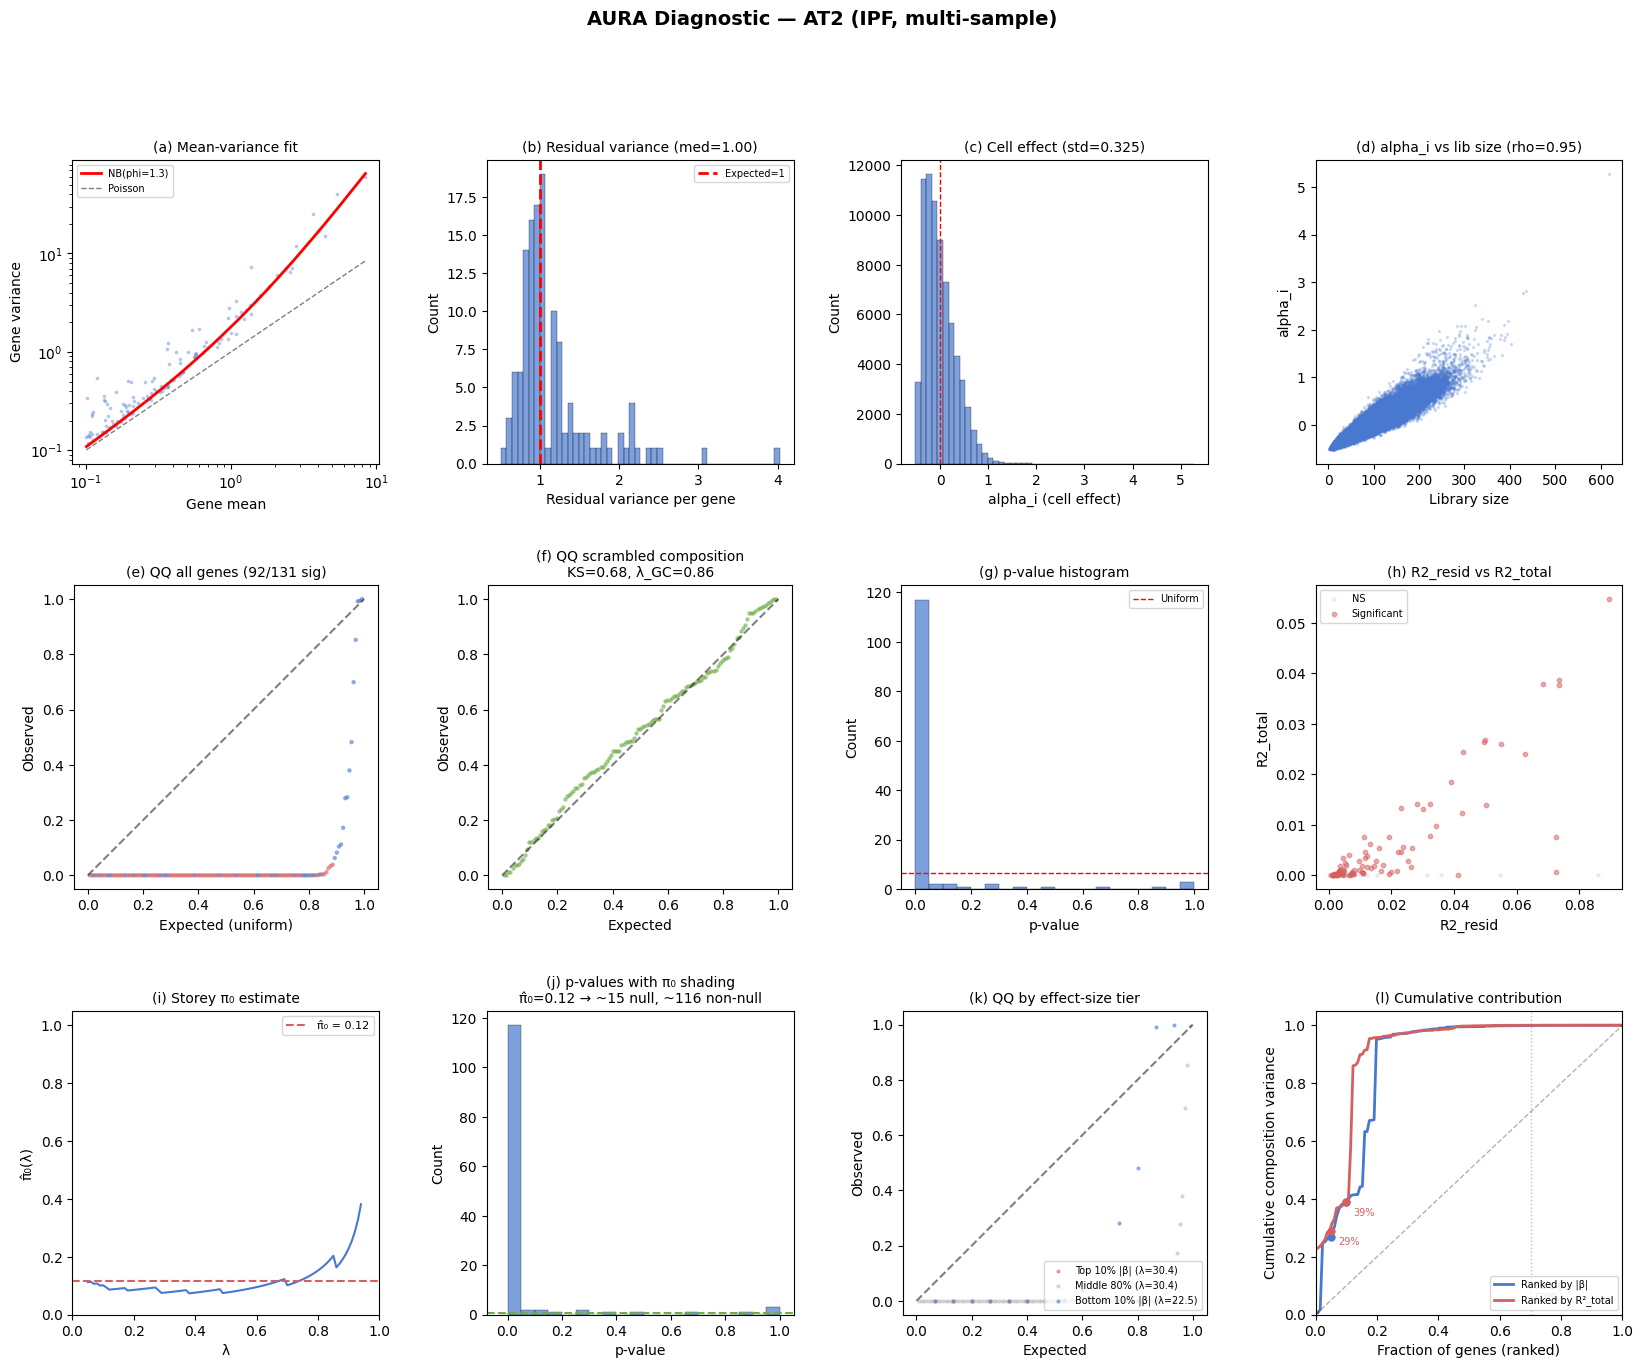

In [6]:
fig = aura.diagnostic_panel(result_at2, title='AURA Diagnostic — AT2 (IPF, multi-sample)')
plt.show()

---
## 4. Beta Heatmap

The **beta heatmap** is the summary visualization of AURA results. Each row
is a significant gene; each column is a composition axis. The color encodes
the direction and magnitude of the effect: red = upregulated when that
neighbor type is abundant, blue = downregulated.

Genes are hierarchically clustered by their beta profiles, revealing
shared regulatory programs.

/var/folders/ng/zvhd5jxx2t938k7tzrkmp7l80000gn/T/ipykernel_53856/644642530.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


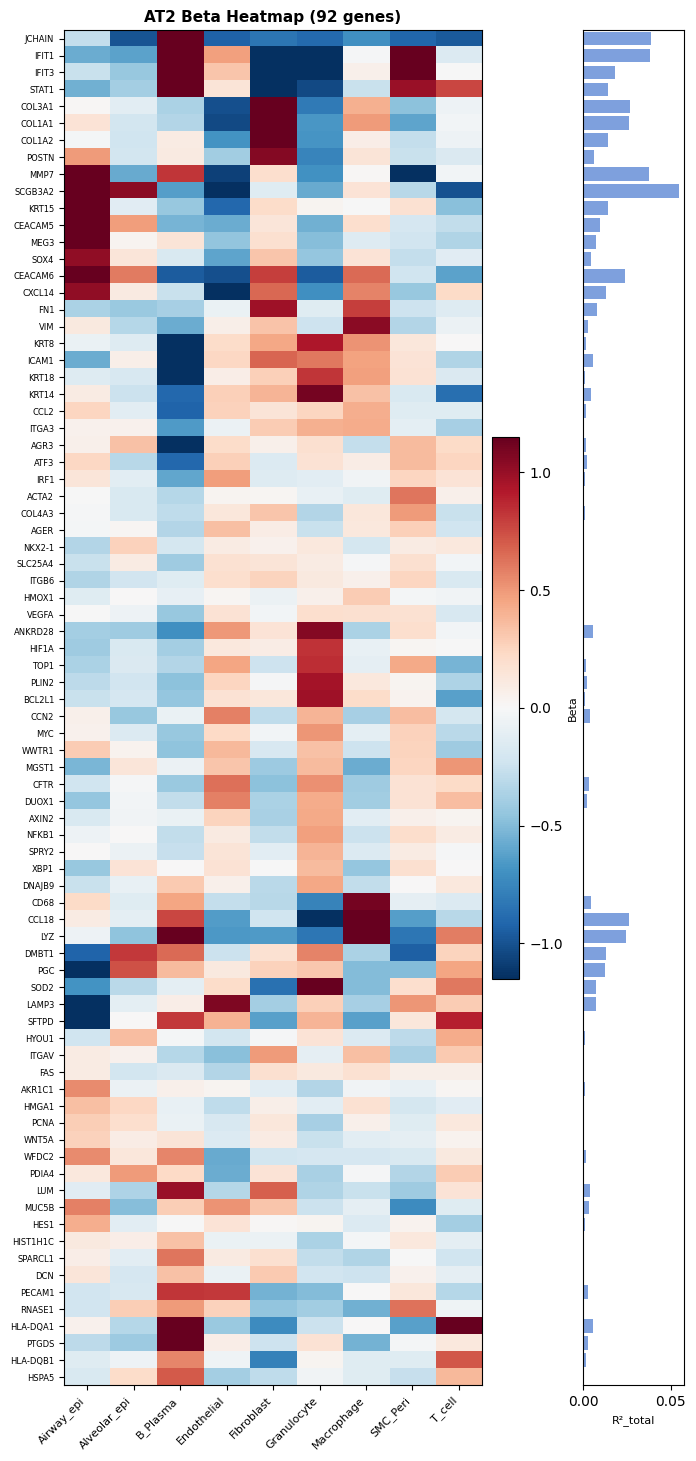

In [7]:
from scipy.cluster.hierarchy import linkage, leaves_list

def beta_heatmap(result, title='Beta Heatmap', max_genes=80, out_path=None):
    """Full beta heatmap of significant genes × composition axes."""
    sig_mask = result.significant
    beta = result.beta[sig_mask]
    genes = result.gene_names[sig_mask]
    r2t = result.R2_total[sig_mask]
    type_names = result.type_names

    # Sort by R2_total, take top max_genes
    order = np.argsort(r2t)[::-1][:max_genes]
    beta_show = beta[order]
    genes_show = genes[order]
    r2_show = r2t[order]

    # Hierarchical clustering for gene order
    if len(beta_show) > 2:
        Z = linkage(beta_show, method='ward')
        clust_order = leaves_list(Z)
        beta_show = beta_show[clust_order]
        genes_show = genes_show[clust_order]
        r2_show = r2_show[clust_order]

    n_genes = len(genes_show)
    vmax = np.percentile(np.abs(beta_show), 95)

    fig, (ax_heat, ax_r2) = plt.subplots(
        1, 2, figsize=(8, max(6, n_genes * 0.22)),
        gridspec_kw={'width_ratios': [5, 1], 'wspace': 0.05})

    im = ax_heat.imshow(beta_show, aspect='auto', cmap='RdBu_r',
                        vmin=-vmax, vmax=vmax, interpolation='none')
    ax_heat.set_xticks(range(len(type_names)))
    ax_heat.set_xticklabels(type_names, rotation=45, ha='right', fontsize=8)
    ax_heat.set_yticks(range(n_genes))
    ax_heat.set_yticklabels(genes_show, fontsize=6)
    ax_heat.set_title(title, fontsize=11, fontweight='bold')

    cb = plt.colorbar(im, ax=ax_heat, shrink=0.4, pad=0.02)
    cb.set_label('Beta', fontsize=8)

    # R2_total sidebar
    ax_r2.barh(range(n_genes), r2_show, color='#4878CF', alpha=0.7, height=0.8)
    ax_r2.set_yticks([])
    ax_r2.set_xlabel('R²_total', fontsize=8)
    ax_r2.invert_yaxis()
    ax_r2.set_ylim(ax_heat.get_ylim())

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
    return fig

fig = beta_heatmap(result_at2, title=f'AT2 Beta Heatmap ({result_at2.n_significant} genes)')
plt.show()

---
## 5. SVD Result Panel

The SVD decomposes the beta matrix into principal composition modes.
For AT2 cells, PC1 typically captures the alveolar ↔ fibrotic gradient.

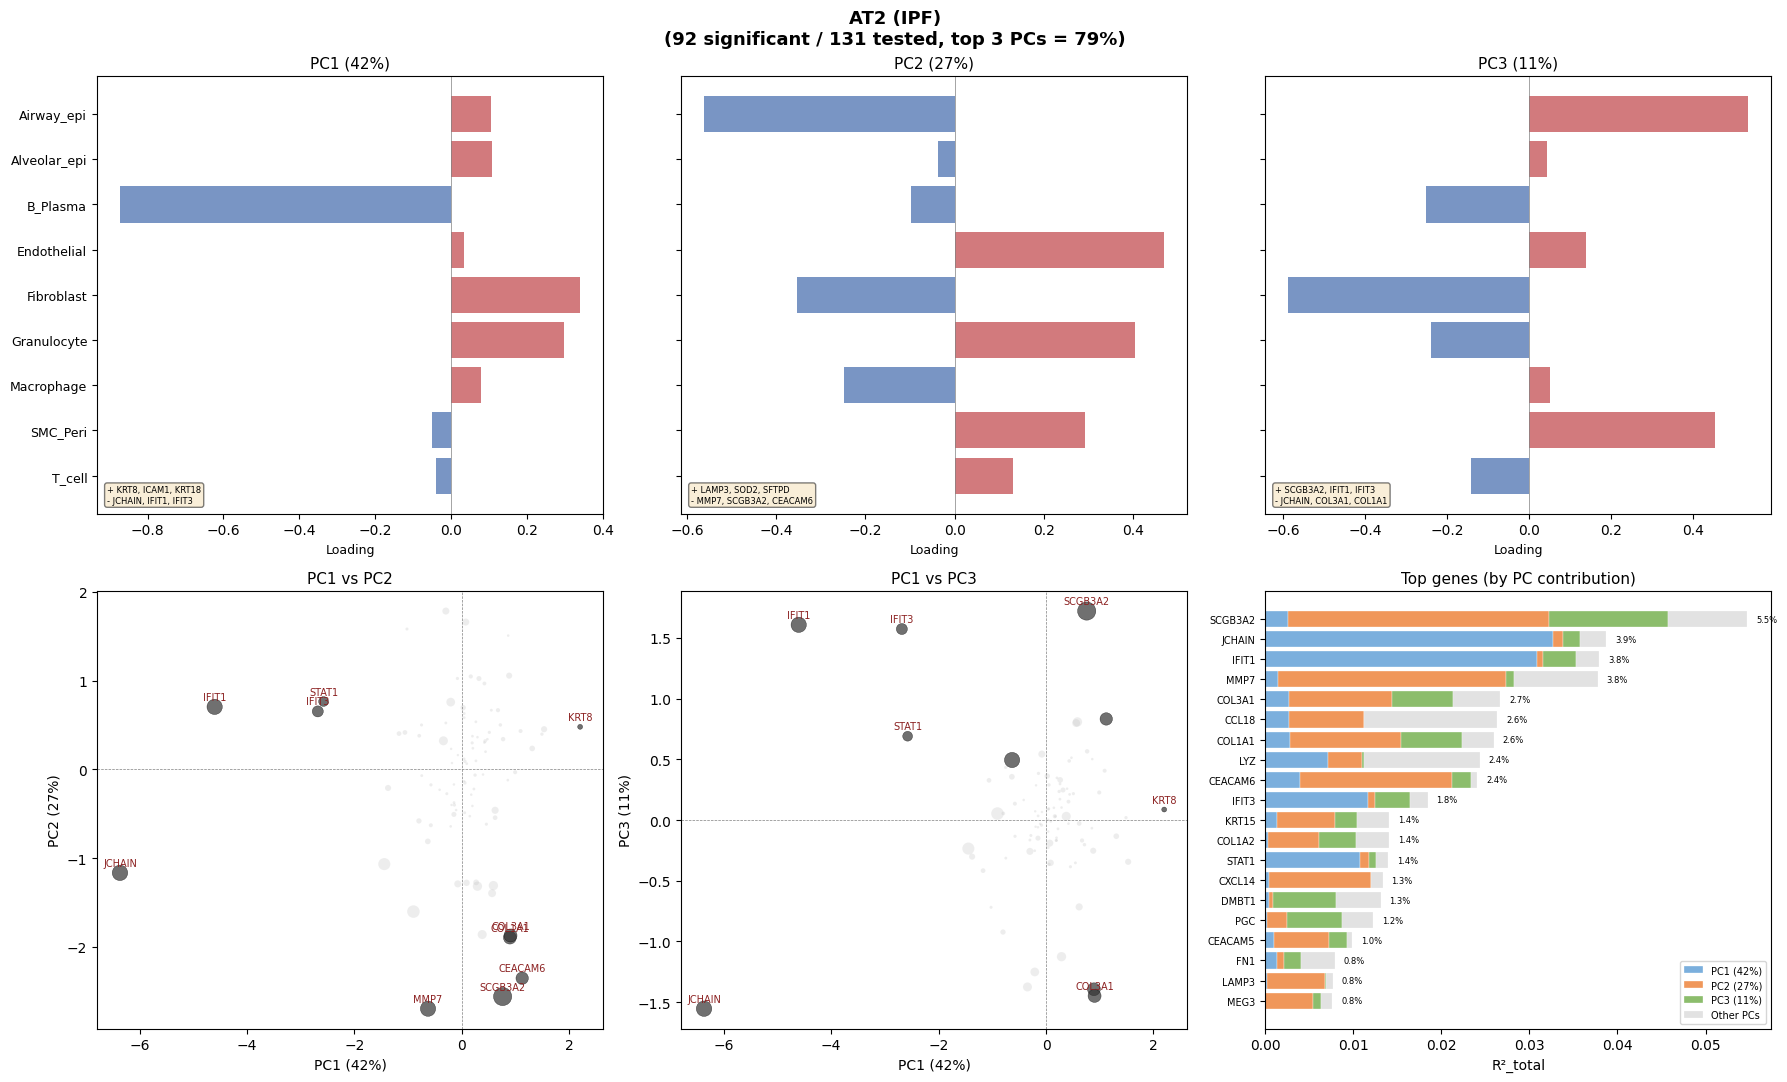

In [8]:
fig = aura.result_panel(result=result_at2, title='AT2 (IPF)')
plt.show()

---
## 6. Run a Second Focal Type: SPP1+ Macrophages

SPP1+ macrophages are a pro-fibrotic macrophage subset enriched in IPF
tissue. Their gene expression is expected to be strongly shaped by the
local fibrotic microenvironment.

aura.io: Focal cells (SPP1+ Macrophages): 24092


aura.io: Genes (mean >= 0.10): 125


aura.model: Dispersion phi = 3.31


aura.model: Samples: 35, Cells: 24092, Types: 9


aura.model: Cells per sample: min=27, max=3630, median=430


aura.model: Significant genes: 75 / 125 (FDR < 0.05)


aura.model: Filtered 1 genes with no excess variance (76 before filter)


/var/folders/ng/zvhd5jxx2t938k7tzrkmp7l80000gn/T/ipykernel_53856/644642530.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Completed in 17s
Focal cells: 24,092
Significant: 75/125


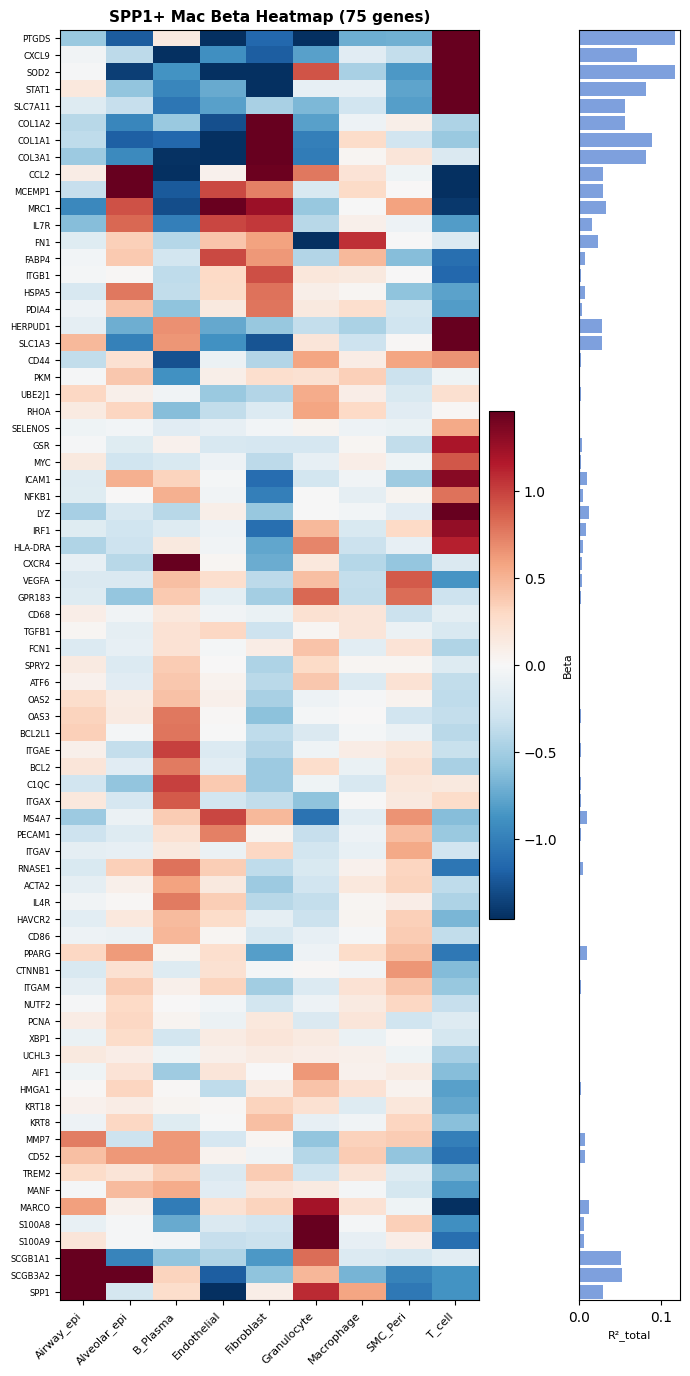

In [9]:
t0 = time.time()
result_spp1 = aura.run_aura_multisample(
    tissue,
    focal_label='SPP1+ Macrophages',
    sample_column='sample',
    label_column='final_CT',
    k=K,
    n_perm=N_PERM,
    alpha=ALPHA,
)
elapsed = time.time() - t0

print(f'\nCompleted in {elapsed:.0f}s')
print(f'Focal cells: {result_spp1.counts.shape[0]:,}')
print(f'Significant: {result_spp1.n_significant}/{result_spp1.n_genes}')

fig = beta_heatmap(result_spp1,
                   title=f'SPP1+ Mac Beta Heatmap ({result_spp1.n_significant} genes)')
plt.show()

---
## 7. Data-Driven Spillover Detection

With default Xenium segmentation (15 µm nuclear expansion), some AURA
hits may reflect transcript **spillover** from neighboring cells rather
than genuine regulation. AURA provides a data-driven filter:

### Step 1: Learn canonical markers from the data

`learn_canonical` identifies genes that are **strongly enriched** in one
composition group (fold ≥ 2 over 2nd-highest, detection ≥ 5%).
These are the genes most susceptible to spillover.

In [10]:
# Use all cells (not just disease) for marker derivation
adata_full = sc.read_h5ad(DATA_PATH)
adata_full.obs['comp_group'] = (
    adata_full.obs['final_CT'].map(LINEAGE_MAP).fillna('Other'))
adata_full = adata_full[adata_full.obs['comp_group'] != 'Other'].copy()

canonical, stats_df = aura.learn_canonical(
    adata_full, type_column='comp_group',
    min_fold=2.0, min_detection=0.05,
)

n_markers = sum(len(v) for v in canonical.values())
print(f'Derived {n_markers} canonical markers across '
      f'{sum(1 for v in canonical.values() if v)} groups:\n')
for grp, markers in sorted(canonical.items()):
    if markers:
        preview = ', '.join(sorted(markers)[:8])
        ell = '...' if len(markers) > 8 else ''
        print(f'  {grp:15s} ({len(markers):3d}): {preview}{ell}')

aura.spillover: Learned 158 canonical markers across 9/9 types (min_fold=2.0, min_det=5%)


Derived 158 canonical markers across 9 groups:

  Airway_epi      ( 32): AGR3, AKR1C1, AKR1C2, BPIFA1, C20orf85, CCNA1, CDH26, CREB3L4...
  Alveolar_epi    ( 16): AGER, COL4A3, DMBT1, GKN2, ICAM1, ITGB6, LAMP3, MSLN...
  B_Plasma        ( 20): BANK1, BCL2L11, CD19, CD79A, CD79B, DERL3, DNAJB9, FKBP11...
  Endothelial     ( 16): ACKR1, APLNR, BMPR2, CA4, CCL21, CD34, CLDN5, EPAS1...
  Fibroblast      ( 13): COL1A1, COL3A1, DCN, FAP, FGF7, HAS2, LUM, MEG3...
  Granulocyte     (  7): CPA3, KIT, S100A12, S100A8, S100A9, SLC25A37, TPSAB1
  Macrophage      ( 25): AIF1, C1QC, CCL18, CD14, CD68, CD86, CST3, FABP4...
  SMC_Peri        (  4): ACTA2, CSPG4, LGR6, PDGFRB
  T_cell          ( 25): CCL5, CD2, CD247, CD28, CD3D, CD3E, CD3G, CD8A...


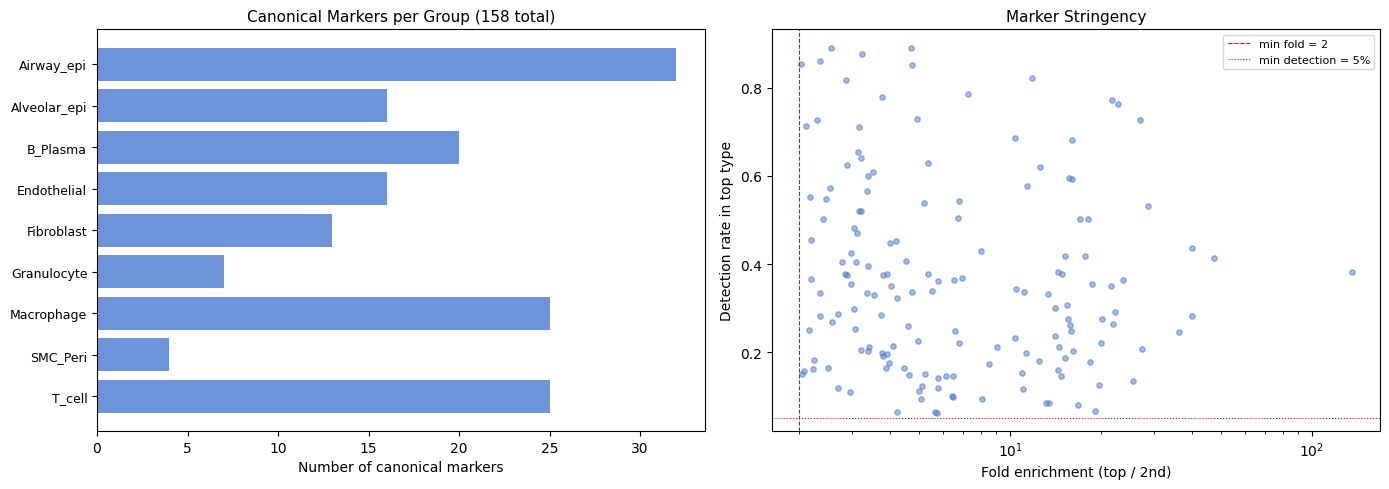

In [11]:
# Visualize marker enrichment
markers_df = stats_df[stats_df['is_marker']].copy()
grp_counts = markers_df['top_type'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar: markers per group
ax1.barh(range(len(grp_counts)), grp_counts.values, color='#4878CF', alpha=0.8)
ax1.set_yticks(range(len(grp_counts)))
ax1.set_yticklabels(grp_counts.index, fontsize=9)
ax1.set_xlabel('Number of canonical markers')
ax1.set_title(f'Canonical Markers per Group ({n_markers} total)', fontsize=11)
ax1.invert_yaxis()

# Scatter: fold enrichment vs detection
for _, row in markers_df.iterrows():
    ax2.scatter(row['fold_enrichment'], row['top_detection'],
                s=15, alpha=0.5, c='#4878CF')
ax2.axvline(2.0, color='red', ls='--', lw=0.8, label='min fold = 2')
ax2.axhline(0.05, color='red', ls=':', lw=0.8, label='min detection = 5%')
ax2.set_xlabel('Fold enrichment (top / 2nd)')
ax2.set_ylabel('Detection rate in top type')
ax2.set_title('Marker Stringency', fontsize=11)
ax2.legend(fontsize=8)
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

### Step 2: Apply spillover filter

A significant gene is **spillover-suspect** if:
1. Its driver axis (max |β|) has the gene in its canonical marker set
2. The gene is NOT a marker of the focal type's own lineage

For example, if SFTPC (an AT2/alveolar marker) shows up as significant in
SPP1+ macrophages driven by the Alveolar_epi axis, that is spillover.

In [12]:
# Filter AT2
spill_at2 = aura.spillover_filter(
    result=result_at2,
    focal_lineage='Alveolar_epi',
    canonical=canonical,
)
n_suspect_at2 = spill_at2['spillover_suspect'].sum()
n_clean_at2 = len(spill_at2) - n_suspect_at2
print(f'AT2: {len(spill_at2)} significant, {n_clean_at2} clean, '
      f'{n_suspect_at2} spillover-suspect ({n_suspect_at2/len(spill_at2)*100:.0f}%)\n')

# Show suspect genes
suspects = spill_at2[spill_at2['spillover_suspect']]
if len(suspects) > 0:
    print('Spillover-suspect genes:')
    print(suspects[['gene', 'driver_axis', 'R2_total', 'reason']].to_string(index=False))

aura.spillover: Spillover filter: 92 significant, 15 suspect (16%), 77 clean


AT2: 92 significant, 77 clean, 15 spillover-suspect (16%)

Spillover-suspect genes:
  gene driver_axis  R2_total                                   reason
JCHAIN    B_Plasma  0.038752   JCHAIN is canonical marker of B_Plasma
  MMP7  Airway_epi  0.037742   MMP7 is canonical marker of Airway_epi
COL3A1  Fibroblast  0.026721 COL3A1 is canonical marker of Fibroblast
 CCL18  Macrophage  0.026353  CCL18 is canonical marker of Macrophage
COL1A1  Fibroblast  0.025964 COL1A1 is canonical marker of Fibroblast
   LYZ  Macrophage  0.024400    LYZ is canonical marker of Macrophage
 KRT15  Airway_epi  0.014068  KRT15 is canonical marker of Airway_epi
  SOX4  Airway_epi  0.004713   SOX4 is canonical marker of Airway_epi
  CD68  Macrophage  0.004671   CD68 is canonical marker of Macrophage
AKR1C1  Airway_epi  0.000873 AKR1C1 is canonical marker of Airway_epi
 HMOX1  Macrophage  0.000304  HMOX1 is canonical marker of Macrophage
 ACTA2    SMC_Peri  0.000298    ACTA2 is canonical marker of SMC_Peri
 EPAS1

In [13]:
# Filter SPP1+ Macrophages
spill_spp1 = aura.spillover_filter(
    result=result_spp1,
    focal_lineage='Macrophage',
    canonical=canonical,
)
n_suspect_spp1 = spill_spp1['spillover_suspect'].sum()
n_clean_spp1 = len(spill_spp1) - n_suspect_spp1
print(f'SPP1+ Mac: {len(spill_spp1)} significant, {n_clean_spp1} clean, '
      f'{n_suspect_spp1} spillover-suspect ({n_suspect_spp1/len(spill_spp1)*100:.0f}%)\n')

suspects_spp1 = spill_spp1[spill_spp1['spillover_suspect']]
if len(suspects_spp1) > 0:
    print('Spillover-suspect genes:')
    print(suspects_spp1[['gene', 'driver_axis', 'R2_total', 'reason']].to_string(index=False))

aura.spillover: Spillover filter: 75 significant, 6 suspect (8%), 69 clean


SPP1+ Mac: 75 significant, 69 clean, 6 spillover-suspect (8%)

Spillover-suspect genes:
   gene driver_axis  R2_total                                    reason
 COL1A1  Fibroblast  0.089006  COL1A1 is canonical marker of Fibroblast
 COL3A1  Fibroblast  0.081165  COL3A1 is canonical marker of Fibroblast
SCGB1A1  Airway_epi  0.051105 SCGB1A1 is canonical marker of Airway_epi
 S100A8 Granulocyte  0.005847 S100A8 is canonical marker of Granulocyte
 S100A9 Granulocyte  0.005266 S100A9 is canonical marker of Granulocyte
 PECAM1 Endothelial  0.001463 PECAM1 is canonical marker of Endothelial


### Step 3: Annotate the beta heatmap with spillover status

Overlay spillover-suspect genes on the heatmap so readers can distinguish
genuine findings from potential artifacts.

/var/folders/ng/zvhd5jxx2t938k7tzrkmp7l80000gn/T/ipykernel_53856/3110209616.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


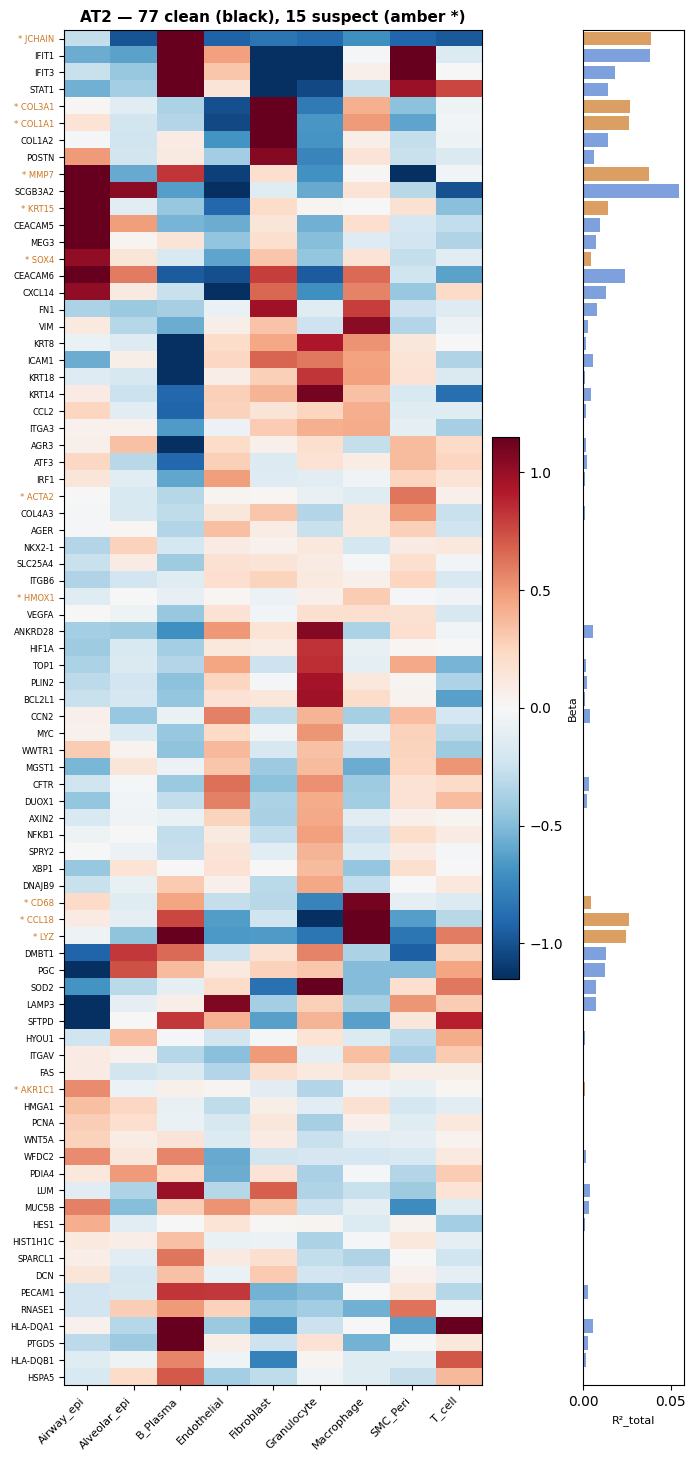

In [14]:
def beta_heatmap_annotated(result, spill_df, title='', max_genes=80):
    """Beta heatmap with spillover-suspect genes marked."""
    sig_mask = result.significant
    beta = result.beta[sig_mask]
    genes = result.gene_names[sig_mask]
    r2t = result.R2_total[sig_mask]
    type_names = result.type_names

    order = np.argsort(r2t)[::-1][:max_genes]
    beta_show = beta[order]
    genes_show = genes[order]
    r2_show = r2t[order]

    # Cluster
    from scipy.cluster.hierarchy import linkage, leaves_list
    if len(beta_show) > 2:
        Z = linkage(beta_show, method='ward')
        clust_order = leaves_list(Z)
        beta_show = beta_show[clust_order]
        genes_show = genes_show[clust_order]
        r2_show = r2_show[clust_order]

    # Suspect set
    suspect_set = set(spill_df[spill_df['spillover_suspect']]['gene'])

    n_genes = len(genes_show)
    vmax = np.percentile(np.abs(beta_show), 95)

    fig, (ax_heat, ax_r2) = plt.subplots(
        1, 2, figsize=(8, max(6, n_genes * 0.22)),
        gridspec_kw={'width_ratios': [5, 1], 'wspace': 0.05})

    im = ax_heat.imshow(beta_show, aspect='auto', cmap='RdBu_r',
                        vmin=-vmax, vmax=vmax, interpolation='none')
    ax_heat.set_xticks(range(len(type_names)))
    ax_heat.set_xticklabels(type_names, rotation=45, ha='right', fontsize=8)
    ax_heat.set_yticks(range(n_genes))

    # Color gene labels: red for suspect, black for clean
    labels = []
    for g in genes_show:
        labels.append(f'* {g}' if g in suspect_set else g)
    ax_heat.set_yticklabels(labels, fontsize=6)
    for i, lab in enumerate(ax_heat.get_yticklabels()):
        if genes_show[i] in suspect_set:
            lab.set_color('#CC7722')

    ax_heat.set_title(title, fontsize=11, fontweight='bold')
    cb = plt.colorbar(im, ax=ax_heat, shrink=0.4, pad=0.02)
    cb.set_label('Beta', fontsize=8)

    # R2 sidebar: color by spillover status
    colors = ['#CC7722' if g in suspect_set else '#4878CF' for g in genes_show]
    ax_r2.barh(range(n_genes), r2_show, color=colors, alpha=0.7, height=0.8)
    ax_r2.set_yticks([])
    ax_r2.set_xlabel('R²_total', fontsize=8)
    ax_r2.invert_yaxis()
    ax_r2.set_ylim(ax_heat.get_ylim())

    plt.tight_layout()
    return fig

fig = beta_heatmap_annotated(
    result_at2, spill_at2,
    title=f'AT2 — {n_clean_at2} clean (black), {n_suspect_at2} suspect (amber *)')
plt.show()

/var/folders/ng/zvhd5jxx2t938k7tzrkmp7l80000gn/T/ipykernel_53856/3110209616.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


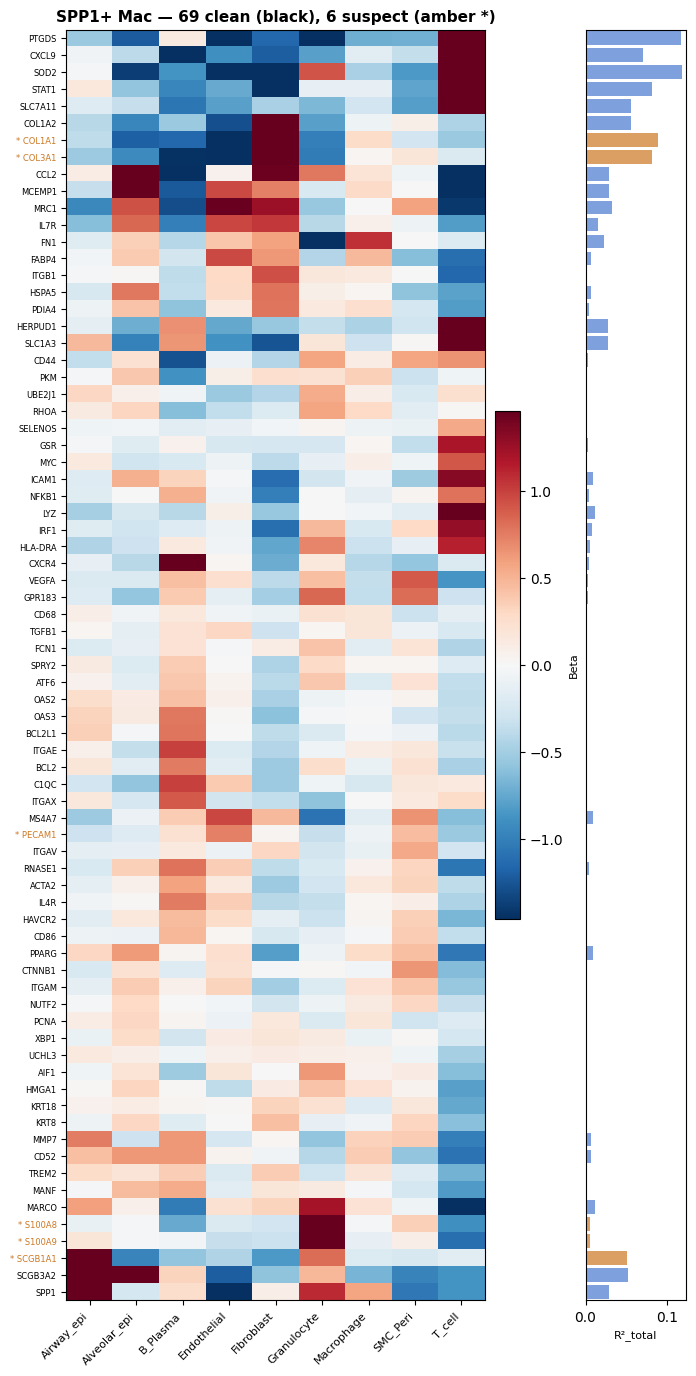

In [15]:
fig = beta_heatmap_annotated(
    result_spp1, spill_spp1,
    title=f'SPP1+ Mac — {n_clean_spp1} clean (black), {n_suspect_spp1} suspect (amber *)')
plt.show()

---
## 8. Distance-Decay Validation

For individual suspect genes, `spillover_distance_test` computes
expression as a function of distance to the nearest cell of the driver
type. **Genuine** composition effects show flat or gradual trends;
**spillover** shows a sharp, non-physiological distance-decay.

In [16]:
# Pick the top-R2 suspect from SPP1+ Macrophages (if any)
if len(suspects_spp1) > 0:
    top_suspect = suspects_spp1.iloc[0]
    gene_name = top_suspect['gene']
    driver_axis = top_suspect['driver_axis']
    driver_idx = tissue.type_to_int[driver_axis]

    # Build focal sample IDs
    from scipy.spatial import cKDTree
    sample_names = sorted(adata.obs['sample'].unique())
    sample_to_int = {s: i for i, s in enumerate(sample_names)}
    all_sample_ids = np.array([sample_to_int[s] for s in adata.obs['sample']])
    tree = cKDTree(tissue.all_xy)
    _, idx = tree.query(result_spp1.focal_xy, k=1)
    focal_sample_ids = all_sample_ids[idx]

    verdict = aura.spillover_distance_test(
        gene_name=gene_name,
        focal_xy=result_spp1.focal_xy,
        focal_counts=result_spp1.counts,
        focal_gene_names=result_spp1.gene_names,
        focal_sample_ids=focal_sample_ids,
        all_xy=tissue.all_xy,
        all_types=tissue.all_types,
        all_sample_ids=all_sample_ids,
        driver_type_idx=driver_idx,
        type_names=np.array(tissue.type_names),
        verbose=True,
    )
else:
    print('No spillover-suspect genes to test.')


  Spillover Distance Test: COL1A1
  Driver type: Fibroblast
  Cells with driver neighbors: 24,092/24,092
  Median distance to nearest driver: 39 µm

      Distance  n_cells   Det%   Mean  Ctrl_det%
      0-10   µm      421 36.1%  0.74     98.8%
     10-20   µm    3,026 38.3%  0.95     99.3%
     20-30   µm    4,454 24.8%  0.48     99.6%
     30-50   µm    8,214 15.6%  0.24     99.7%
     50-100  µm    6,322  7.9%  0.10     99.5%
    100-200  µm    1,520  2.9%  0.03     99.5%
    200-500  µm      135  1.5%  0.01    100.0%

  COL1A1 fold-decay (near/far): 24.4x
  Control (VIM) fold-change: 1.0x

  ** LIKELY SPILLOVER: decays 24x while control is stable.


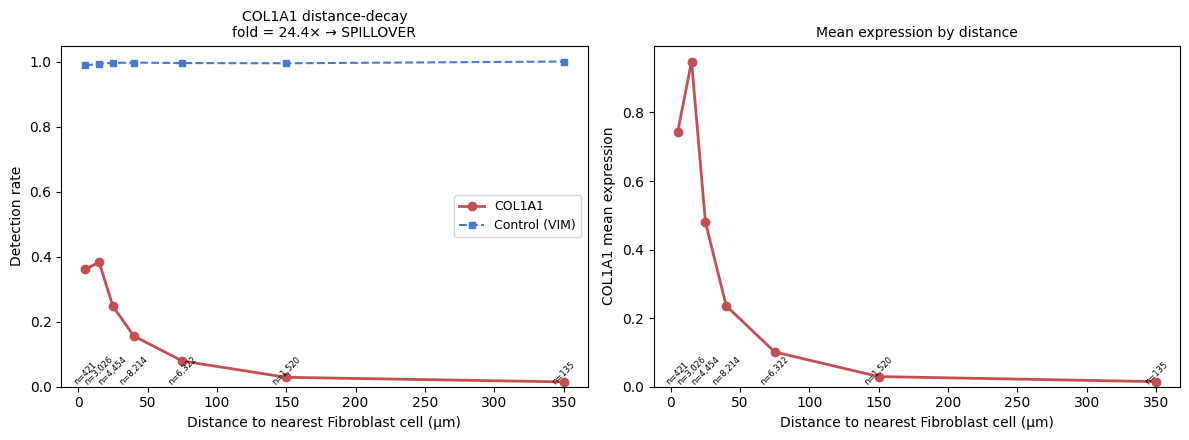

In [17]:
# Plot distance-decay curve
if len(suspects_spp1) > 0 and len(verdict['bins_df']) >= 2:
    bins_df = verdict['bins_df']
    mid = (bins_df['dist_lo'] + bins_df['dist_hi']) / 2

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    # Target gene
    ax1.plot(mid, bins_df['detection_rate'], 'o-', color='#C44E52',
             lw=2, markersize=6, label=gene_name)
    ax1.plot(mid, bins_df['control_detection'], 's--', color='#4878CF',
             lw=1.5, markersize=5, label=f'Control ({verdict["control_gene"]})')
    ax1.set_xlabel(f'Distance to nearest {driver_axis} cell (µm)')
    ax1.set_ylabel('Detection rate')
    ax1.set_title(f'{gene_name} distance-decay\n'
                  f'fold = {verdict["fold_decay"]:.1f}× → {verdict["verdict"].upper()}',
                  fontsize=10)
    ax1.legend(fontsize=9)
    ax1.set_ylim(bottom=0)

    # Mean expression
    ax2.plot(mid, bins_df['mean_expr'], 'o-', color='#C44E52',
             lw=2, markersize=6)
    ax2.set_xlabel(f'Distance to nearest {driver_axis} cell (µm)')
    ax2.set_ylabel(f'{gene_name} mean expression')
    ax2.set_title('Mean expression by distance', fontsize=10)
    ax2.set_ylim(bottom=0)

    for ax in [ax1, ax2]:
        n_per_bin = bins_df['n_cells'].values
        for i, (x, n) in enumerate(zip(mid, n_per_bin)):
            ax.text(x, ax.get_ylim()[0], f'n={n:,}', fontsize=6,
                    ha='center', va='bottom', rotation=45)

    plt.tight_layout()
    plt.show()

---
## 9. Multi-Focal Spillover Summary

`spillover_filter_multi` runs the filter across multiple focal types
in one call — the standard pattern for multi-focal scans.

In [18]:
# Combine both focal types
combined = aura.spillover_filter_multi(
    [
        ('AT2', result_at2, 'Alveolar_epi'),
        ('SPP1_Mac', result_spp1, 'Macrophage'),
    ],
    canonical=canonical,
)

print(f'Combined spillover summary:')
print(f'  Total significant: {len(combined)}')
print(f'  Clean: {(~combined["spillover_suspect"]).sum()}')
print(f'  Suspect: {combined["spillover_suspect"].sum()} '
      f'({combined["spillover_suspect"].mean()*100:.0f}%)\n')

for ft in ['AT2', 'SPP1_Mac']:
    sub = combined[combined['focal_type'] == ft]
    ns = sub['spillover_suspect'].sum()
    print(f'  {ft:12s}: {len(sub)} total, {len(sub)-ns} clean, {ns} suspect')

aura.spillover: Spillover filter: 92 significant, 15 suspect (16%), 77 clean


aura.spillover: Spillover filter: 75 significant, 6 suspect (8%), 69 clean


aura.spillover: spillover_filter_multi: 2 focal types, 167 total significant, 146 clean, 21 spillover-suspect


Combined spillover summary:
  Total significant: 167
  Clean: 146
  Suspect: 21 (13%)

  AT2         : 92 total, 77 clean, 15 suspect
  SPP1_Mac    : 75 total, 69 clean, 6 suspect


---
## 10. Save Results

In [19]:
import os
os.makedirs('results', exist_ok=True)

result_at2.save('results/aura_AT2.csv')
result_spp1.save('results/aura_SPP1_Mac.csv')
combined.to_csv('results/spillover_summary.csv', index=False)

print('Saved:')
print('  results/aura_AT2.csv')
print('  results/aura_SPP1_Mac.csv')
print('  results/spillover_summary.csv')

aura.io: Saved results: results/aura_AT2.csv (131 genes, 92 significant)


aura.io: Saved results: results/aura_SPP1_Mac.csv (125 genes, 75 significant)


Saved:
  results/aura_AT2.csv
  results/aura_SPP1_Mac.csv
  results/spillover_summary.csv


---
## Summary

This tutorial demonstrated AURA features specific to multi-sample and
spillover-prone datasets:

1. **Multi-sample mode** — `run_aura_multisample` with within-sample kNN
   and permutation, preventing cross-core confounding
2. **Beta heatmap** — hierarchically clustered gene × composition matrix
   for full-result visualization
3. **Data-driven spillover detection** — `learn_canonical` derives markers
   from the data; `spillover_filter` flags suspect genes; `spillover_filter_multi`
   handles multi-focal scans
4. **Distance-decay validation** — `spillover_distance_test` confirms
   suspects by checking for non-physiological spatial decay

### When to use the spillover filter

| Platform | Segmentation | Expected suspect rate |
|:---|:---|:---|
| Xenium + NEBULA | Identity-weighted | ~2% |
| CosMx | Bespoke | ~12% |
| Xenium default | 15 µm expansion | ~17% |

The filter is most important for default Xenium segmentation; for
NEBULA-processed or well-segmented data, it serves mainly as a sanity check.